# Mosquito Supermodel: Predict Demo

Run YOLOv11 `predict` on the bundled demo assets and produce detections plus a merged `results.csv`. Use this as a quick-start to validate your install or as a reference for wiring the API into your own workflows.

**Requirements**
- Install the package from the repo root: `pip install -e .`
- Make sure that you are on the right interpreter
- Make sure YOLito weights are at `weights/last.pt` 
- The demo media lives in `src/demo` (`blood_feeding.png`, `dead.jpeg`, `flying.MOV`).

In [9]:
import sys
sys.path.append('../..')
from pathlib import Path
import yaml

from mosquito_supermodel import build_runtime_config, run_task


def find_repo_root(start: Path) -> Path:
    # Walk upward until we find the repo root that contains configs/.
    for candidate in [start, *start.parents]:
        if (candidate / "configs").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
demo_dir = repo_root / "src" / "demo"
weights_path = repo_root / "weights" / "last.pt"
output_dir = repo_root / "output" / "demo_predict"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"repo_root={repo_root}")
print(f"demo_dir={demo_dir}")
print(f"weights_path={weights_path}")
print(f"output_dir={output_dir}")



repo_root=/home/bohbot/Evyatar/git/Mosquito_Supermodel
demo_dir=/home/bohbot/Evyatar/git/Mosquito_Supermodel/src/demo
weights_path=/home/bohbot/Evyatar/git/Mosquito_Supermodel/weights/last.pt
output_dir=/home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict


In [ ]:
# Choose which demo asset to run. Use demo_dir to process the whole folder.
image_or_video = demo_dir / "blood_feeding.png"

config = {
    "images_dir": str(image_or_video),
    "model": {
        "conf_threshold": 0.25,
        "iou_threshold": 0.5,
        "task": "predict",  # options: predict | track | slice
        "vid_stride": 1,
        "weights": str(weights_path),
    },
    "output_dir": str(output_dir),
    "sahi": {
        "overlap_ratio": 0.1,
        "slice_size_h": 640,
        "slice_size_w": 640,
        "track": True,
    },
    "change_analyze_conf": False,
    "save_animations": True,
}

config_path = output_dir / "infer_demo.yaml"
config_path.write_text(yaml.safe_dump(config))
config_path



PosixPath('/home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/infer_demo.yaml')

In [11]:
runtime_config = build_runtime_config("infer", config_path)
run_task(runtime_config)



Exported config to /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/infer_config.yaml

image 1/1 /home/bohbot/Evyatar/git/Mosquito_Supermodel/src/demo/dead.jpeg: 640x480 35 1s, 27.4ms
Speed: 3.8ms preprocess, 27.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/predict
Results saved to: /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict
Results saved to /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/predict/results.csv
No CSVs to merge.
Removed empty folder: /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/csvs
Removed empty folder: /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/predict
Removed empty folder: /home/bohbot/Evyatar/git/Mosquito_Supermodel/output/demo_predict/videos


,image_idx,box_idx,x,y,w,h,confidence,label,track_id,image_name,img_h,img_w
0,0,0,628.57620,421.23602,96.465640,62.84317,0.846768,0.0,NaN,dead,1600,1200
1,0,1,612.76050,625.33600,94.766600,89.59241,0.846551,0.0,NaN,dead,1600,1200
2,0,2,366.71585,476.71533,39.274292,64.33127,0.836004,0.0,NaN,dead,1600,1200
3,0,3,550.23430,911.37160,95.684360,82.17865,0.835027,0.0,NaN,dead,1600,1200
4,0,4,892.77900,729.19476,40.478638,75.43396,0.825003,0.0,NaN,dead,1600,1200


Annotated frames: 2


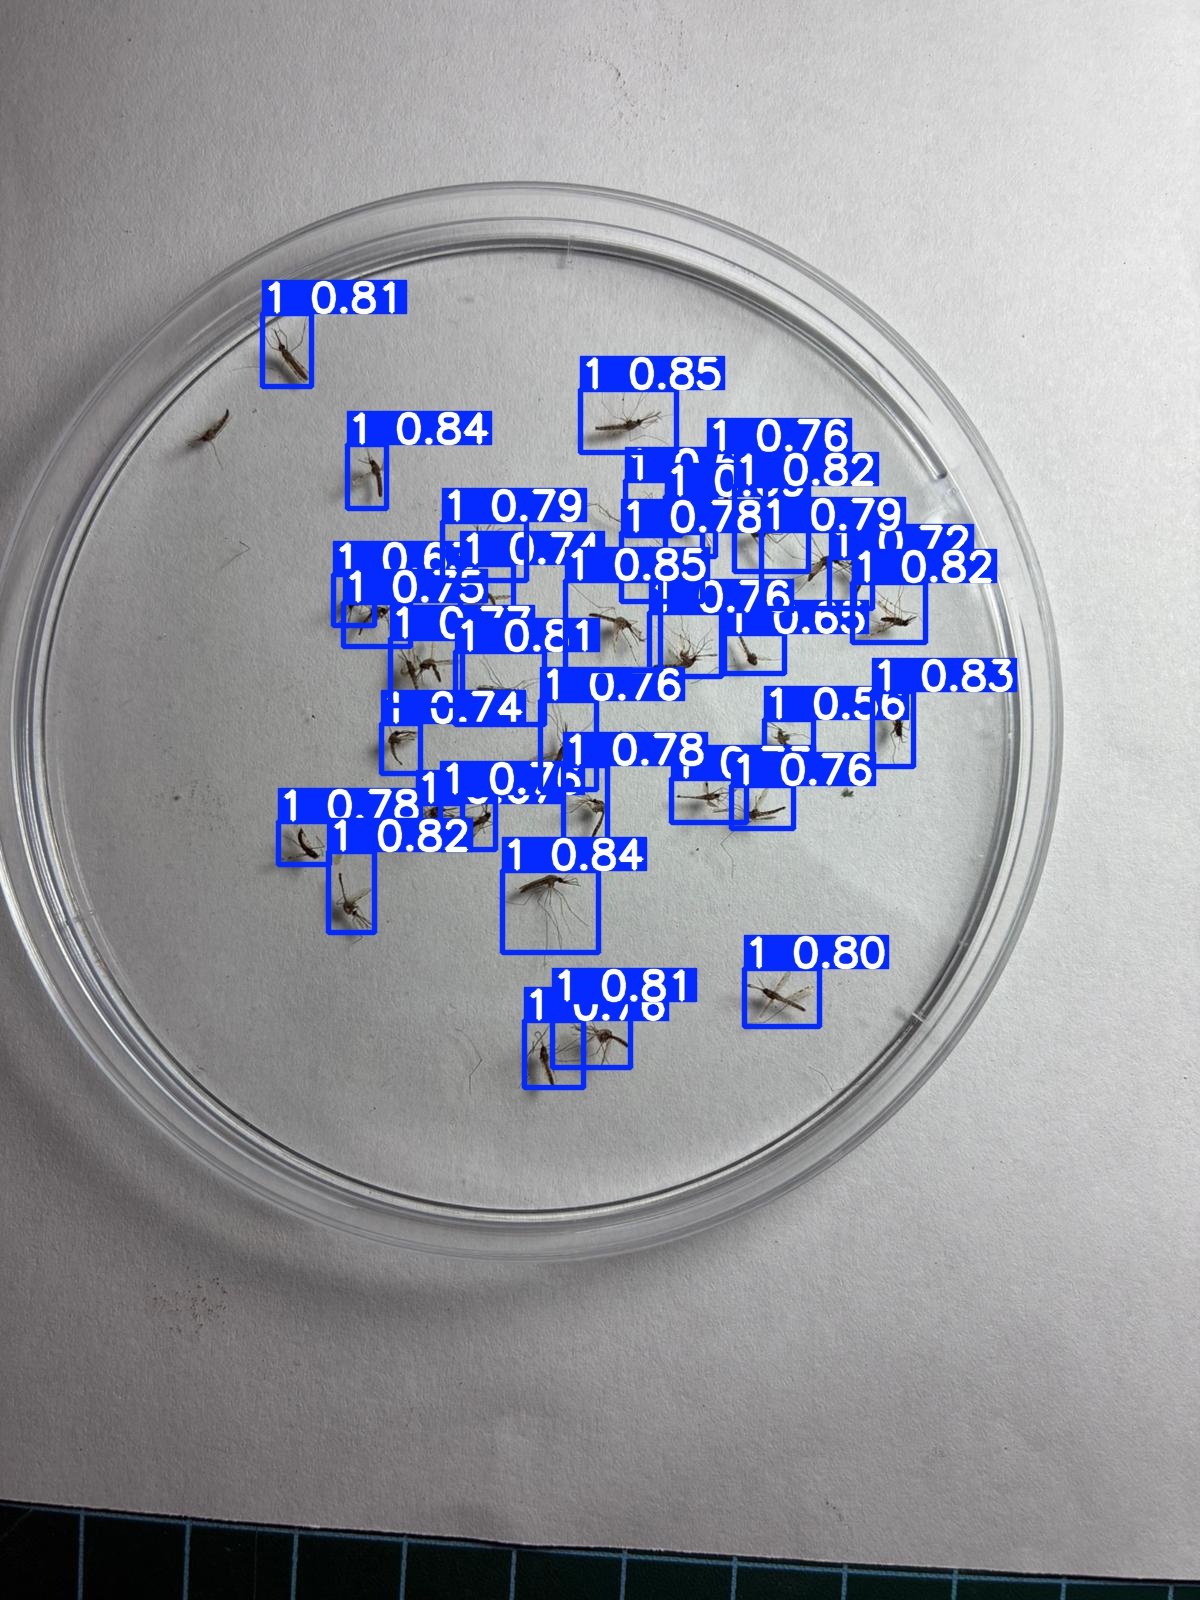

In [12]:
import pandas as pd

results_csv = Path(output_dir) / "results.csv"
display(pd.read_csv(results_csv).head())

frames_dir = Path(output_dir) / "frames"
predictions = sorted(frames_dir.glob("*.jpg"))
print(f"Annotated frames: {len(predictions)}")
if predictions:
    from IPython.display import Image, display as show
    show(Image(filename=predictions[0]))

